https://youtu.be/-bDngqXiYrQ

# **Tutorial 5: Spatial Heterogeneity Analysis + Machine Learning for Region Discovery**

## 📚 **Series Context**
This tutorial is part of a comprehensive YouTube series on **3D Organoid Data Analysis**, bridging wet-lab biology with computational data science using Python. We're using real published data from:

> **Ong et al., Nature Methods 2025**: "Digitalized organoids: integrated pipeline for high-speed 3D analysis of organoid structures using multilevel segmentation and cellular topology"
>
> 🔗 [Read the paper](https://www.nature.com/articles/s41592-025-02685-4)

---

## 🎯 **Tutorial 5 Goal**

**Discover and characterize distinct cellular subpopulations within a single heterogeneous tumor organoid using unsupervised and supervised machine learning.**

### Research Question
Can we automatically identify morphologically distinct cellular populations (e.g., core, border, invasive regions) in a large PDAC (pancreatic ductal adenocarcinoma) organoid without any prior labels?

### Why This Matters
- **Tumor Biology**: Tumors aren't uniform—they have heterogeneous regions with different behaviors
- **Drug Resistance**: Core regions may be hypoxic and drug-resistant
- **Invasion & Metastasis**: Border cells and buds may drive cancer spread
- **Precision Medicine**: Understanding heterogeneity is key to effective treatment

---

## 📊 **Dataset: Figure 5b**

- **Source**: Single PDAC organoid from Ong et al. 2025
- **Scale**: 3,071 cells
- **Features**: 29 morphological, intensity, and topology descriptors per cell
  - **Intensity**: DAPI staining patterns (nuclear chromatin state)
  - **Topology**: Local neighborhood organization (20 µm radius)
  - **Shape**: Prolate/oblate ratios, axis measurements (3D geometry)

### Data Limitation
⚠️ **No spatial coordinates (X, Y, Z)**: We cannot directly study core-border gradients or map cells to specific regions. However, we can still discover morphological and functional heterogeneity through shape, intensity, and topology features.

---

## 🔬 **Scientific Approach**

### **Part 1: Data Exploration**
- Load Figure 5b dataset (single PDAC organoid)
- Understand feature types and data quality
- Set biological expectations

### **Part 2: Shape Analysis - Prolate/Oblate**
- **Prolate ratio**: Measures rod-like elongation (cigar shape)
- **Oblate ratio**: Measures disk-like flattening (pancake shape)
- Use data-driven thresholds (25th/75th percentiles) to classify cells
- Visualize 3D shape distribution patterns

### **Part 3: Unsupervised Learning - K-means Clustering**
- Optimize cluster number (elbow method + silhouette scores)
- Run K-means clustering on all 29 features
- Visualize with PCA and UMAP dimensionality reduction
- **Key Teaching Moment**: Interpreting weak clustering as biological continuums

### **Part 4: Cluster Validation**
- Compare clusters against shape categories
- Calculate Adjusted Rand Index (measure of agreement)
- Understand what drives cluster differences

### **Part 5: Cluster Characterization**
- **Statistical comparison**: ANOVA + effect sizes (eta-squared)
- Identify top features separating clusters
- Quantify magnitude of differences
- **Outcome**: Which features show the strongest variation between populations?

### **Part 6: Feature Importance for Clustering**
- **Machine Learning validation**: Train Random Forest classifier
- Predict cluster membership from features
- Extract feature importance rankings
- **Outcome**: Can we reliably predict which population a cell belongs to?

### **Part 7: Biological Synthesis**
- Integrate findings from Parts 1-6
- Biological interpretation of three cellular states
- Acknowledge limitations (no spatial data, single organoid)
- Explain clinical relevance and future directions

---



### IMPORT LIBRARIES


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cdist

# Machine Learning - Unsupervised
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score

# Machine Learning - Supervised
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Dimensionality Reduction
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("Note: UMAP not available. Install with: pip install umap-learn")

# Model Interpretability
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("Note: SHAP not available. Install with: pip install shap")

import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [ ]:
# ============================================================
# LOAD DATA
# ============================================================

def load_fig5b_data(data_path):
    """
    Load Figure 5b dataset containing single PDAC organoid with spatial heterogeneity.

    This is ONE large, complex organoid with 3,071 cells showing regional differences.
    Features include:
    - Intensity metrics (DAPI staining patterns)
    - Topology at 20 µm radius (local neighborhood)
    - Shape metrics (prolate and oblate ratios)

    Args:
        data_path: Path to the directory containing Excel files

    Returns:
        df: DataFrame with heterogeneity data
        feature_cols: List of feature column names
        metadata_cols: List of metadata column names
    """
    file_path = f"{data_path}/Fig-5-41592_2025_2685_MOESM12_ESM.xlsx"

    print(f"\n{'='*70}")
    print("LOADING SPATIAL HETEROGENEITY DATASET")
    print(f"{'='*70}")

    # Load Excel file
    #df = pd.read_excel(file_path)
    df = pd.read_excel(file_path, sheet_name="5b (grey)")


    print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

    # Identify metadata columns
    # Typically: Batch, Sample, Well, Field, Cell, Position_X, Position_Y, Position_Z
    metadata_cols = [col for col in df.columns if not col.startswith('Value of')]

    # Feature columns: all columns starting with "Value of"
    feature_cols = [col for col in df.columns if col.startswith('Value of')]

    print(f"\nMetadata columns ({len(metadata_cols)}):")
    for col in metadata_cols:
        print(f"  - {col}")

    print(f"\nFeature columns ({len(feature_cols)}):")

    # Group features by type for display
    intensity_features = [col for col in feature_cols if 'intensity' in col.lower() or 'cv' in col.lower() or 'mean' in col.lower()]
    topology_features = [col for col in feature_cols if 'neighbor' in col.lower() or 'distance' in col.lower() or 'density' in col.lower()]
    shape_features = [col for col in feature_cols if 'prolate' in col.lower() or 'oblate' in col.lower() or 'axis' in col.lower() or 'ratio' in col.lower()]

    if intensity_features:
        print(f"\n  Intensity features ({len(intensity_features)}):")
        for col in intensity_features[:5]:  # Show first 5
            print(f"    • {col.replace('Value of Default_', '')[:50]}")
        if len(intensity_features) > 5:
            print(f"    ... and {len(intensity_features)-5} more")

    if topology_features:
        print(f"\n  Topology features ({len(topology_features)}):")
        for col in topology_features[:5]:
            print(f"    • {col.replace('Value of Default_', '')[:50]}")
        if len(topology_features) > 5:
            print(f"    ... and {len(topology_features)-5} more")

    if shape_features:
        print(f"\n  Shape features ({len(shape_features)}):")
        for col in shape_features:
            print(f"    • {col.replace('Value of Default_', '')[:50]}")

    print(f"\n{'─'*70}")
    print("DATASET CHARACTERISTICS")
    print(f"{'─'*70}")

    print(f"\nThis is a SINGLE large organoid with spatial heterogeneity")
    print(f"Total cells analyzed: {len(df)}")

    # Check if we have position data
    position_cols = [col for col in metadata_cols if 'position' in col.lower() or '_x' in col.lower() or '_y' in col.lower() or '_z' in col.lower()]
    if position_cols:
        print(f"\n✓ Spatial position data available: {position_cols}")
    else:
        print(f"\n⚠ No explicit position columns found - will need to infer from features")

    return df, feature_cols, metadata_cols

# Execute: Load the data
data_path = "/content/drive/MyDrive/ColabNotebooks/data/3D_Organoid_Analysis"
df_fig5b, feature_columns, metadata_columns = load_fig5b_data(data_path)


LOADING SPATIAL HETEROGENEITY DATASET
Dataset loaded: 3071 rows × 34 columns

Metadata columns (5):
  - Batch
  - Sample
  - Well
  - Field
  - Cell

Feature columns (29):

  Intensity features (10):
    • max_intensity_value_C1
    • min_intensity_value_C1
    • average_intensity_value_C1
    • standard_deviation_intensity_value_C1
    • sum_intensity_value_C1
    ... and 5 more

  Topology features (5):
    • distance_to_neighbors_centroids_20.0_μm
    • neighbors_average_distance_to_nuclei_20.0_μm
    • n_nuclei_neighbors_20.0_μm
    • nb_nuclei_neighbors_ripley_20.0_μm
    • crystal_distance_20.0_μm

  Shape features (8):
    • major_axis_in_20.0_μm
    • medium_axis_in_20.0_μm
    • minor_axis_in_20.0_μm
    • ratio_minor_by_medium_in_20.0_μm
    • ratio_medium_by_major_in_20.0_μm
    • ratio_minor_by_major_in_20.0_μm
    • prolate_ratio_20.0_μm
    • oblate_ratio_20.0_μm

──────────────────────────────────────────────────────────────────────
DATASET CHARACTERISTICS
─────────────


### PART 1: UNDERSTANDING THE DATASET


In [ ]:


def explore_heterogeneity_dataset(df, feature_cols):
    """
    Explore the spatial heterogeneity dataset to understand its structure.

    This organoid is expected to show regional differences:
    - Core cells: Dense packing, lower oxygen, potential necrosis
    - Border cells: Higher proliferation, better nutrient access
    - Buds: Invasive structures, different organization

    Args:
        df: DataFrame with organoid data
        feature_cols: List of feature column names
    """
    print(f"\n{'='*70}")
    print("PART 1: UNDERSTANDING THE DATASET")
    print(f"{'='*70}")

    print("\n📊 SINGLE ORGANOID HETEROGENEITY:")
    print(f"{'─'*70}\n")

    print("Unlike previous tutorials where we compared multiple organoids,")
    print("here we're analyzing ONE large tumor organoid with ~3,000 cells.")
    print("\nBiological expectation:")
    print("  • CORE: Dense, potentially hypoxic, lower proliferation")
    print("  • BORDER: Active growth, better oxygen/nutrients")
    print("  • BUDS: Invasive protrusions, distinct organization")

    # Basic statistics
    print(f"\n{'─'*70}")
    print("DATASET OVERVIEW")
    print(f"{'─'*70}\n")

    print(f"Total cells: {len(df)}")
    print(f"Total features: {len(feature_cols)}")

    # Check for missing values
    missing_counts = df[feature_cols].isnull().sum()
    if missing_counts.sum() > 0:
        print(f"\n⚠ Features with missing values:")
        for col, count in missing_counts[missing_counts > 0].items():
            feature_name = col.replace('Value of Default_', '')[:40]
            print(f"  {feature_name}: {count} missing ({count/len(df)*100:.1f}%)")
    else:
        print(f"\n✓ No missing values in feature columns")

    # Feature distribution statistics
    print(f"\n{'─'*70}")
    print("FEATURE STATISTICS (selected features)")
    print(f"{'─'*70}\n")

    # Select representative features if we have prolate/oblate
    key_features = []
    for col in feature_cols:
        if 'prolate' in col.lower() or 'oblate' in col.lower():
            key_features.append(col)

    if not key_features:
        # If no prolate/oblate, show first 5 features
        key_features = feature_cols[:5]

    if key_features:
        stats_df = df[key_features].describe()
        print(stats_df.to_string())

    print(f"\n✓ Dataset exploration complete")

# Execute: Explore the dataset
explore_heterogeneity_dataset(df_fig5b, feature_columns)


PART 1: UNDERSTANDING THE DATASET

📊 SINGLE ORGANOID HETEROGENEITY:
──────────────────────────────────────────────────────────────────────

Unlike previous tutorials where we compared multiple organoids,
here we're analyzing ONE large tumor organoid with ~3,000 cells.

Biological expectation:
  • CORE: Dense, potentially hypoxic, lower proliferation
  • BORDER: Active growth, better oxygen/nutrients
  • BUDS: Invasive protrusions, distinct organization

──────────────────────────────────────────────────────────────────────
DATASET OVERVIEW
──────────────────────────────────────────────────────────────────────

Total cells: 3071
Total features: 29

⚠ Features with missing values:
  major_axis_in_20.0_μm: 2 missing (0.1%)
  medium_axis_in_20.0_μm: 2 missing (0.1%)
  minor_axis_in_20.0_μm: 2 missing (0.1%)
  ratio_minor_by_medium_in_20.0_μm: 2 missing (0.1%)
  ratio_medium_by_major_in_20.0_μm: 2 missing (0.1%)
  ratio_minor_by_major_in_20.0_μm: 2 missing (0.1%)
  prolate_ratio_20.0_μm: 2

### PART 2: PROLATE/OBLATE ANALYSIS (PAPER'S APPROACH)



PART 2: PROLATE/OBLATE ANALYSIS (PAPER'S APPROACH)

📐 WHAT ARE PROLATE AND OBLATE RATIOS?
──────────────────────────────────────────────────────────────────────

These ratios describe 3D shape anisotropy:
  • PROLATE: (major - medium) / (major - minor)
    → High values = rod-like (elongated)
  • OBLATE: (medium - minor) / (major - minor)
    → High values = disk-like (flattened)

Shape categories:
  • Rod: High prolate, low oblate
  • Disk: Low prolate, high oblate
  • Sphere: Both moderate (~0.5)

──────────────────────────────────────────────────────────────────────
PROLATE/OBLATE DISTRIBUTION
──────────────────────────────────────────────────────────────────────

Prolate ratio:
  Mean: 0.254
  Median: 0.199
  Range: [0.000, 0.877]

Oblate ratio:
  Mean: 0.182
  Median: 0.093
  Range: [0.000, 0.904]

Data-driven thresholds (25th/75th percentiles):
  Prolate: low (25th percentile) = 0.114
           high (75th percentile) = 0.355
  Oblate:  low (25th percentile) = 0.032
           h

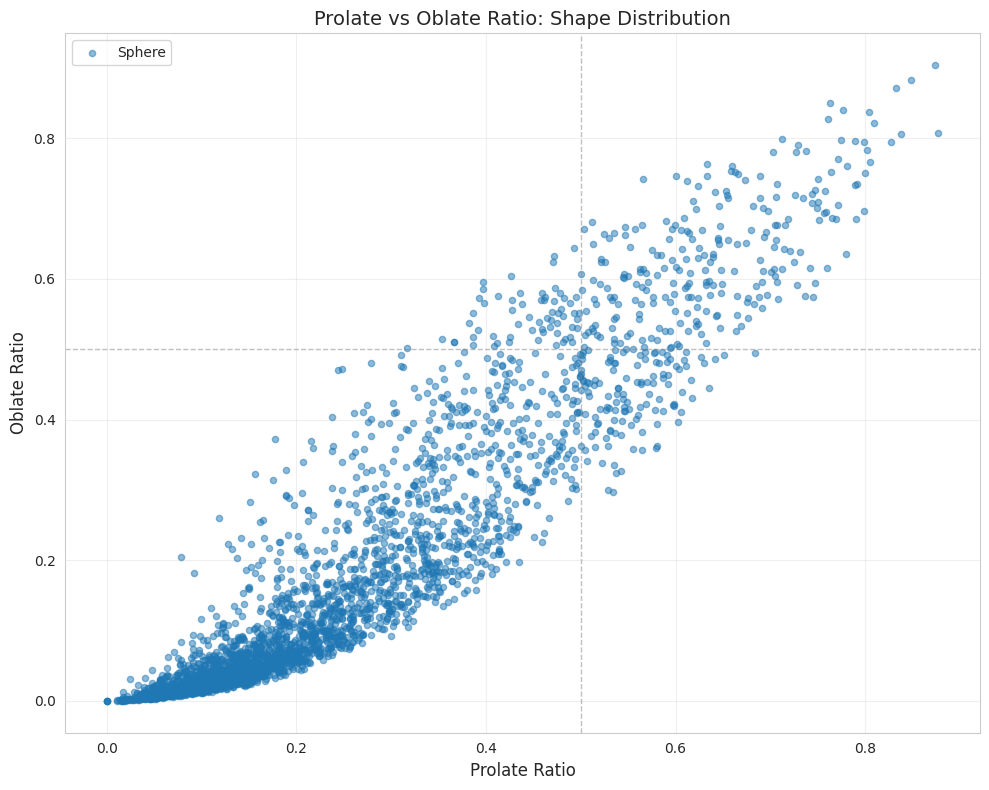

✓ Prolate/oblate analysis complete


In [ ]:


def analyze_prolate_oblate(df, feature_cols):
    """
    Analyze prolate and oblate ratios following the paper's approach.

    Prolate ratio: Measures rod-like shapes (cigar-shaped)
    Oblate ratio: Measures disk-like shapes (pancake-shaped)

    These ratios capture how cells and their neighborhoods are shaped in 3D:
    - High prolate, low oblate: Elongated (rod)
    - Low prolate, high oblate: Flattened (disk)
    - Both moderate: Spherical

    Args:
        df: DataFrame with organoid data
        feature_cols: List of feature column names

    Returns:
        df: DataFrame with shape category labels
        prolate_col: Name of prolate ratio column
        oblate_col: Name of oblate ratio column
    """
    print(f"\n{'='*70}")
    print("PART 2: PROLATE/OBLATE ANALYSIS (PAPER'S APPROACH)")
    print(f"{'='*70}")

    print("\n📐 WHAT ARE PROLATE AND OBLATE RATIOS?")
    print(f"{'─'*70}\n")

    print("These ratios describe 3D shape anisotropy:")
    print("  • PROLATE: (major - medium) / (major - minor)")
    print("    → High values = rod-like (elongated)")
    print("  • OBLATE: (medium - minor) / (major - minor)")
    print("    → High values = disk-like (flattened)")
    print("\nShape categories:")
    print("  • Rod: High prolate, low oblate")
    print("  • Disk: Low prolate, high oblate")
    print("  • Sphere: Both moderate (~0.5)")

    # Find prolate and oblate columns
    prolate_col = None
    oblate_col = None

    for col in feature_cols:
        if 'prolate' in col.lower():
            prolate_col = col
        if 'oblate' in col.lower():
            oblate_col = col

    if prolate_col is None or oblate_col is None:
        print("\n⚠ Prolate/oblate columns not found in standard format")
        print("Looking for shape ratio columns...")

        # Try to find alternative shape columns
        shape_cols = [col for col in feature_cols if 'ratio' in col.lower()]
        if len(shape_cols) >= 2:
            prolate_col = shape_cols[0]
            oblate_col = shape_cols[1]
            print(f"Using: {prolate_col}")
            print(f"Using: {oblate_col}")
        else:
            print("Could not identify shape ratio columns")
            return df, None, None

    print(f"\n{'─'*70}")
    print("PROLATE/OBLATE DISTRIBUTION")
    print(f"{'─'*70}\n")

    prolate_values = df[prolate_col].dropna()
    oblate_values = df[oblate_col].dropna()

    print(f"Prolate ratio:")
    print(f"  Mean: {prolate_values.mean():.3f}")
    print(f"  Median: {prolate_values.median():.3f}")
    print(f"  Range: [{prolate_values.min():.3f}, {prolate_values.max():.3f}]")

    print(f"\nOblate ratio:")
    print(f"  Mean: {oblate_values.mean():.3f}")
    print(f"  Median: {oblate_values.median():.3f}")
    print(f"  Range: [{oblate_values.min():.3f}, {oblate_values.max():.3f}]")

    # Gate cells into categories (simple threshold-based)
    # Following typical shape analysis conventions
    df_copy = df.copy()

    # Define thresholds based on actual data distribution (25th/75th percentiles)
    prolate_threshold_high = np.percentile(prolate_values, 75)  # ~0.35
    prolate_threshold_low = np.percentile(prolate_values, 25)   # ~0.11
    oblate_threshold_high = np.percentile(oblate_values, 75)    # ~0.28
    oblate_threshold_low = np.percentile(oblate_values, 25)     # ~0.03

    #print(f"\nData-driven thresholds:")
    #print(f"  Prolate: low={prolate_threshold_low:.3f}, high={prolate_threshold_high:.3f}")
    #print(f"  Oblate: low={oblate_threshold_low:.3f}, high={oblate_threshold_high:.3f}")

    print(f"\nData-driven thresholds (25th/75th percentiles):")
    print(f"  Prolate: low (25th percentile) = {prolate_threshold_low:.3f}")
    print(f"           high (75th percentile) = {prolate_threshold_high:.3f}")
    print(f"  Oblate:  low (25th percentile) = {oblate_threshold_low:.3f}")
    print(f"           high (75th percentile) = {oblate_threshold_high:.3f}")
    print(f"\nClassification rules:")
    print(f"  • Rod:    Prolate > {prolate_threshold_high:.3f} AND Oblate < {oblate_threshold_low:.3f}")
    print(f"  • Disk:   Prolate < {prolate_threshold_low:.3f} AND Oblate > {oblate_threshold_high:.3f}")
    print(f"  • Sphere: Everything else (intermediate values)")



    def categorize_shape(row):
        p = row[prolate_col]
        o = row[oblate_col]

        if pd.isna(p) or pd.isna(o):
            return 'Unknown'

        if p > prolate_threshold_high and o < oblate_threshold_low:
            return 'Rod'
        elif p < prolate_threshold_low and o > oblate_threshold_high:
            return 'Disk'
        else:
            return 'Sphere'

    df_copy['Shape_Category'] = df_copy.apply(categorize_shape, axis=1)

    print(f"\n{'─'*70}")
    print("SHAPE CATEGORY DISTRIBUTION")
    print(f"{'─'*70}\n")

    shape_counts = df_copy['Shape_Category'].value_counts()
    for category, count in shape_counts.items():
        print(f"  {category}: {count} cells ({count/len(df_copy)*100:.1f}%)")

    # Visualize prolate vs oblate scatter
    print("\nGenerating prolate vs oblate scatter plot...\n")

    fig, ax = plt.subplots(figsize=(10, 8))

    # Color by shape category
    for category in ['Rod', 'Disk', 'Sphere']:
        mask = df_copy['Shape_Category'] == category
        if mask.sum() > 0:
            ax.scatter(df_copy.loc[mask, prolate_col],
                      df_copy.loc[mask, oblate_col],
                      label=category, alpha=0.5, s=20)

    ax.set_xlabel('Prolate Ratio', fontsize=12)
    ax.set_ylabel('Oblate Ratio', fontsize=12)
    ax.set_title('Prolate vs Oblate Ratio: Shape Distribution', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Add reference lines
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)

    plt.tight_layout()
    plt.show()

    print("✓ Prolate/oblate analysis complete")

    return df_copy, prolate_col, oblate_col

# Execute: Analyze prolate/oblate ratios
df_fig5b, prolate_column, oblate_column = analyze_prolate_oblate(df_fig5b, feature_columns)


DETERMINING OPTIMAL NUMBER OF CLUSTERS

Testing k from 2 to {max_k}...
This may take a minute...

  k=2: Inertia=72768, Silhouette=0.184
  k=3: Inertia=62897, Silhouette=0.185
  k=4: Inertia=56229, Silhouette=0.185
  k=5: Inertia=52297, Silhouette=0.170
  k=6: Inertia=48568, Silhouette=0.174
  k=7: Inertia=45690, Silhouette=0.163
  k=8: Inertia=43902, Silhouette=0.152

──────────────────────────────────────────────────────────────────────
Recommended k: 3 (highest silhouette score: 0.185)
──────────────────────────────────────────────────────────────────────


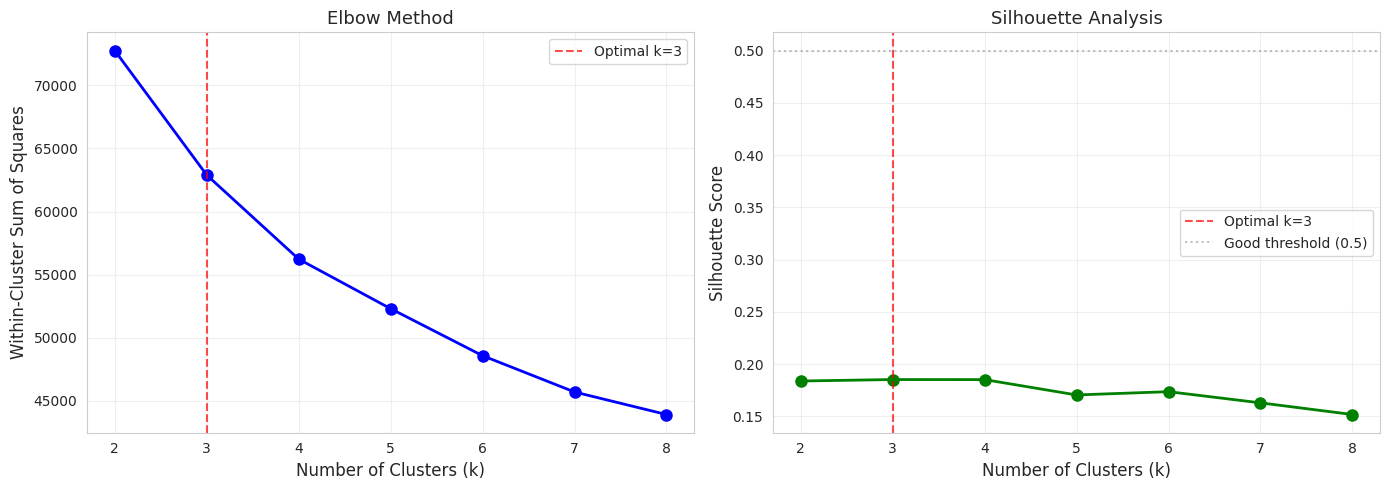


PART 3: K-MEANS CLUSTERING (k=3)

⚠ Missing values detected, imputing with feature means...

📊 Standardizing features...
Scaled feature matrix: (3071, 29)
Mean: -0.000, Std: 1.000

🔄 Running K-means with 3 clusters...

──────────────────────────────────────────────────────────────────────
CLUSTERING RESULTS
──────────────────────────────────────────────────────────────────────

Silhouette score: 0.185
  Interpretation: Weak cluster separation

Cluster sizes:
  Cluster 0: 793 cells (25.8%)
  Cluster 1: 1095 cells (35.7%)
  Cluster 2: 1183 cells (38.5%)

✓ K-means clustering complete

VISUALIZING CLUSTERS WITH PCA AND UMAP

Running PCA (2 components)...
  Explained variance: 49.1%
  PC1: 25.5%
  PC2: 23.6%

Running UMAP (2 components)...
  This may take a minute...
  ✓ UMAP complete

Generating visualization...



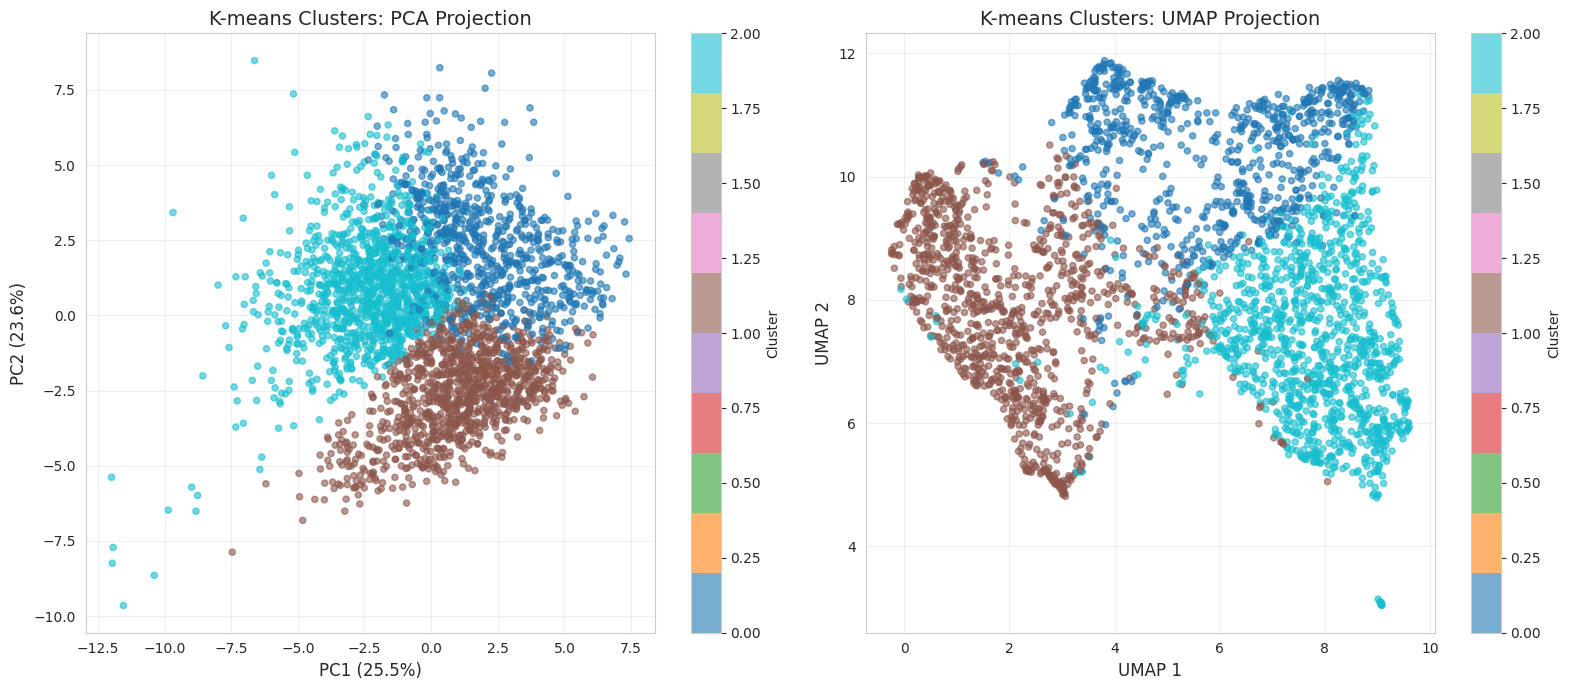

✓ Visualization complete


In [ ]:

# ============================================================
# PART 3: UNSUPERVISED LEARNING - DISCOVERING REGIONS
# ============================================================

def determine_optimal_clusters(X_scaled, max_k=10):
    """
    Use elbow method and silhouette scores to find optimal number of clusters.

    Elbow method: Plot within-cluster sum of squares (inertia)
    - Look for "elbow" where adding clusters gives diminishing returns

    Silhouette score: Measures how similar cells are to their cluster vs other clusters
    - Range [-1, 1], higher is better
    - >0.5 = good separation, 0.3-0.5 = moderate, <0.3 = weak

    Args:
        X_scaled: Standardized feature matrix
        max_k: Maximum number of clusters to try

    Returns:
        optimal_k: Recommended number of clusters
        inertias: List of inertia values
        silhouette_scores: List of silhouette scores
    """
    print(f"\n{'='*70}")
    print("DETERMINING OPTIMAL NUMBER OF CLUSTERS")
    print(f"{'='*70}\n")

    print("Testing k from 2 to {max_k}...")
    print("This may take a minute...\n")

    inertias = []
    silhouette_scores = []
    k_values = range(2, max_k + 1)

    for k in k_values:
        # Fit K-means
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X_scaled)

        # Calculate metrics
        inertias.append(kmeans.inertia_)
        sil_score = silhouette_score(X_scaled, cluster_labels)
        silhouette_scores.append(sil_score)

        print(f"  k={k}: Inertia={kmeans.inertia_:.0f}, Silhouette={sil_score:.3f}")

    # Find optimal k (highest silhouette score)
    optimal_k = k_values[np.argmax(silhouette_scores)]

    print(f"\n{'─'*70}")
    print(f"Recommended k: {optimal_k} (highest silhouette score: {max(silhouette_scores):.3f})")
    print(f"{'─'*70}")

    # Plot metrics
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Elbow plot
    axes[0].plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
    axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
    axes[0].set_ylabel('Within-Cluster Sum of Squares', fontsize=12)
    axes[0].set_title('Elbow Method', fontsize=13)
    axes[0].grid(True, alpha=0.3)
    axes[0].axvline(optimal_k, color='red', linestyle='--', alpha=0.7, label=f'Optimal k={optimal_k}')
    axes[0].legend()

    # Silhouette plot
    axes[1].plot(k_values, silhouette_scores, 'go-', linewidth=2, markersize=8)
    axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
    axes[1].set_ylabel('Silhouette Score', fontsize=12)
    axes[1].set_title('Silhouette Analysis', fontsize=13)
    axes[1].grid(True, alpha=0.3)
    axes[1].axvline(optimal_k, color='red', linestyle='--', alpha=0.7, label=f'Optimal k={optimal_k}')
    axes[1].axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Good threshold (0.5)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return optimal_k, inertias, silhouette_scores


def perform_kmeans_clustering(df, feature_cols, n_clusters=3):
    """
    Perform K-means clustering to discover natural cell groupings.

    K-means finds clusters by minimizing within-cluster variance:
    1. Initialize k cluster centers randomly
    2. Assign each cell to nearest center
    3. Update centers as mean of assigned cells
    4. Repeat until convergence

    Args:
        df: DataFrame with organoid data
        feature_cols: List of feature column names
        n_clusters: Number of clusters to find

    Returns:
        df_clustered: DataFrame with cluster labels
        X_scaled: Standardized features
        scaler: Fitted StandardScaler
        kmeans: Fitted KMeans model
    """
    print(f"\n{'='*70}")
    print(f"PART 3: K-MEANS CLUSTERING (k={n_clusters})")
    print(f"{'='*70}")

    # Prepare data
    X = df[feature_cols].values

    # Handle any missing values
    if np.isnan(X).any():
        print("\n⚠ Missing values detected, imputing with feature means...")
        from sklearn.impute import SimpleImputer
        imputer = SimpleImputer(strategy='mean')
        X = imputer.fit_transform(X)

    # Standardize features
    print("\n📊 Standardizing features...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print(f"Scaled feature matrix: {X_scaled.shape}")
    print(f"Mean: {X_scaled.mean():.3f}, Std: {X_scaled.std():.3f}")

    # Fit K-means
    print(f"\n🔄 Running K-means with {n_clusters} clusters...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    # Add cluster labels to dataframe
    df_clustered = df.copy()
    df_clustered['Cluster'] = cluster_labels

    # Calculate silhouette score
    sil_score = silhouette_score(X_scaled, cluster_labels)

    print(f"\n{'─'*70}")
    print("CLUSTERING RESULTS")
    print(f"{'─'*70}\n")

    print(f"Silhouette score: {sil_score:.3f}")
    if sil_score > 0.5:
        print("  Interpretation: Good cluster separation")
    elif sil_score > 0.3:
        print("  Interpretation: Moderate cluster separation")
    else:
        print("  Interpretation: Weak cluster separation")

    print(f"\nCluster sizes:")
    cluster_counts = df_clustered['Cluster'].value_counts().sort_index()
    for cluster_id, count in cluster_counts.items():
        print(f"  Cluster {cluster_id}: {count} cells ({count/len(df_clustered)*100:.1f}%)")

    print("\n✓ K-means clustering complete")

    return df_clustered, X_scaled, scaler, kmeans


def visualize_clusters_pca_umap(df_clustered, X_scaled, n_clusters):
    """
    Visualize clusters using PCA and UMAP dimensionality reduction.

    PCA: Linear projection to 2D, preserves global structure
    UMAP: Non-linear projection, preserves local neighborhoods

    Args:
        df_clustered: DataFrame with cluster labels
        X_scaled: Standardized feature matrix
        n_clusters: Number of clusters
    """
    print(f"\n{'='*70}")
    print("VISUALIZING CLUSTERS WITH PCA AND UMAP")
    print(f"{'='*70}\n")

    # PCA
    print("Running PCA (2 components)...")
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    print(f"  Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")
    print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
    print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")

    # UMAP (if available)
    if UMAP_AVAILABLE:
        print("\nRunning UMAP (2 components)...")
        print("  This may take a minute...")
        reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
        X_umap = reducer.fit_transform(X_scaled)
        print("  ✓ UMAP complete")
    else:
        X_umap = None
        print("\n⚠ UMAP not available, skipping UMAP visualization")

    # Plot
    print("\nGenerating visualization...\n")

    if X_umap is not None:
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    else:
        fig, axes = plt.subplots(1, 1, figsize=(10, 8))
        axes = [axes]

    # PCA plot
    ax = axes[0]
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                        c=df_clustered['Cluster'], cmap='tab10',
                        alpha=0.6, s=20)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
    ax.set_title('K-means Clusters: PCA Projection', fontsize=14)
    plt.colorbar(scatter, ax=ax, label='Cluster')
    ax.grid(True, alpha=0.3)

    # UMAP plot
    if X_umap is not None:
        ax = axes[1]
        scatter = ax.scatter(X_umap[:, 0], X_umap[:, 1],
                            c=df_clustered['Cluster'], cmap='tab10',
                            alpha=0.6, s=20)
        ax.set_xlabel('UMAP 1', fontsize=12)
        ax.set_ylabel('UMAP 2', fontsize=12)
        ax.set_title('K-means Clusters: UMAP Projection', fontsize=14)
        plt.colorbar(scatter, ax=ax, label='Cluster')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("✓ Visualization complete")

    return X_pca, X_umap, pca

# Execute: Determine optimal clusters and perform clustering
X_scaled_data = StandardScaler().fit_transform(
    df_fig5b[feature_columns].fillna(df_fig5b[feature_columns].mean())
)

optimal_k, inertia_values, silhouette_values = determine_optimal_clusters(X_scaled_data, max_k=8)

# Perform clustering with optimal k
df_fig5b_clustered, X_scaled_fig5b, scaler_fig5b, kmeans_model = perform_kmeans_clustering(
    df_fig5b, feature_columns, n_clusters=optimal_k
)

# Visualize clusters
X_pca_fig5b, X_umap_fig5b, pca_model = visualize_clusters_pca_umap(
    df_fig5b_clustered, X_scaled_fig5b, optimal_k
)



PART 4: VALIDATING CLUSTERS AGAINST BIOLOGY

📊 COMPARING UNSUPERVISED CLUSTERS WITH SHAPE CATEGORIES:
──────────────────────────────────────────────────────────────────────

Cluster vs Shape Category:
Shape_Category  Sphere  Total
Cluster                      
0                  793    793
1                 1095   1095
2                 1181   1181
Total             3069   3069

──────────────────────────────────────────────────────────────────────
Adjusted Rand Index: 0.000
──────────────────────────────────────────────────────────────────────

Interpretation: Weak agreement - clusters capture different patterns than shapes

💡 WHAT THIS MEANS:
  • ARI = 1: Perfect agreement
  • ARI = 0: Random agreement
  • ARI < 0: Less agreement than random

Generating cluster-shape agreement visualization...



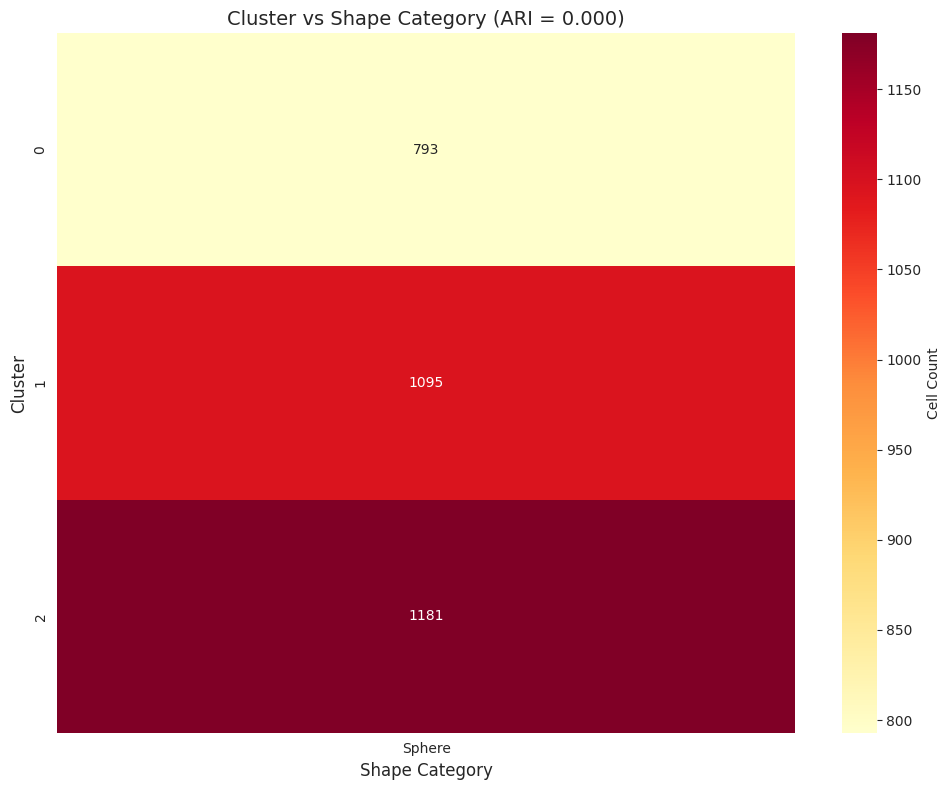

✓ Validation complete


In [ ]:
# ============================================================
# PART 4: VALIDATING AGAINST BIOLOGY
# ============================================================

def validate_clusters_vs_shapes(df, prolate_col, oblate_col):
    """
    Compare unsupervised clusters with prolate/oblate shape categories.

    If clusters align with shape categories, it suggests the clustering
    discovered biologically meaningful structure. Use Adjusted Rand Index
    to measure agreement.

    Args:
        df: DataFrame with both Cluster and Shape_Category columns
        prolate_col: Name of prolate ratio column
        oblate_col: Name of oblate ratio column

    Returns:
        ari_score: Adjusted Rand Index
    """
    print(f"\n{'='*70}")
    print("PART 4: VALIDATING CLUSTERS AGAINST BIOLOGY")
    print(f"{'='*70}")

    if 'Shape_Category' not in df.columns or 'Cluster' not in df.columns:
        print("\n⚠ Missing required columns for validation")
        return None

    print("\n📊 COMPARING UNSUPERVISED CLUSTERS WITH SHAPE CATEGORIES:")
    print(f"{'─'*70}\n")

    # Filter out unknown shapes
    df_valid = df[df['Shape_Category'] != 'Unknown'].copy()

    # Create crosstab
    crosstab = pd.crosstab(df_valid['Cluster'], df_valid['Shape_Category'],
                           margins=True, margins_name='Total')

    print("Cluster vs Shape Category:")
    print(crosstab)

    # Calculate Adjusted Rand Index
    # Convert shape categories to numeric for ARI calculation
    shape_numeric = pd.Categorical(df_valid['Shape_Category']).codes
    cluster_numeric = df_valid['Cluster'].values

    ari_score = adjusted_rand_score(shape_numeric, cluster_numeric)

    print(f"\n{'─'*70}")
    print(f"Adjusted Rand Index: {ari_score:.3f}")
    print(f"{'─'*70}\n")

    if ari_score > 0.5:
        print("Interpretation: Strong agreement - clusters align well with shapes")
    elif ari_score > 0.2:
        print("Interpretation: Moderate agreement - some alignment between clusters and shapes")
    else:
        print("Interpretation: Weak agreement - clusters capture different patterns than shapes")

    print("\n💡 WHAT THIS MEANS:")
    print("  • ARI = 1: Perfect agreement")
    print("  • ARI = 0: Random agreement")
    print("  • ARI < 0: Less agreement than random")

    # Visualize agreement
    print("\nGenerating cluster-shape agreement visualization...\n")

    # Heatmap of crosstab (without margins)
    crosstab_norm = crosstab.iloc[:-1, :-1]  # Remove margins

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(crosstab_norm, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
               cbar_kws={'label': 'Cell Count'})
    ax.set_xlabel('Shape Category', fontsize=12)
    ax.set_ylabel('Cluster', fontsize=12)
    ax.set_title(f'Cluster vs Shape Category (ARI = {ari_score:.3f})', fontsize=14)
    plt.tight_layout()
    plt.show()

    print("✓ Validation complete")

    return ari_score

# Execute: Validate clusters against shape categories
if prolate_column and oblate_column:
    ari_validation = validate_clusters_vs_shapes(df_fig5b_clustered, prolate_column, oblate_column)




EXECUTING PART 5: CLUSTER CHARACTERIZATION

PART 5: CLUSTER CHARACTERIZATION

📊 COMPARING CLUSTERS ACROSS ALL FEATURES:
──────────────────────────────────────────────────────────────────────

Computing statistics for each feature...

──────────────────────────────────────────────────────────────────────
TOP 15 FEATURES THAT SEPARATE CLUSTERS (p < 0.05)
──────────────────────────────────────────────────────────────────────

Feature                                    η²       p-value   
──────────────────────────────────────────────────────────────────────
oblate_ratio_20.0_μm                       0.627    0.00e+00  
minor_axis_in_20.0_μm                      0.625    0.00e+00  
ratio_minor_by_major_in_20.0_μm            0.621    0.00e+00  
prolate_ratio_20.0_μm                      0.618    0.00e+00  
average_intensity_value_C1                 0.588    0.00e+00  
max_intensity_value_C1                     0.566    0.00e+00  
standard_deviation_intensity_value_C1      0.564    0.00e+00

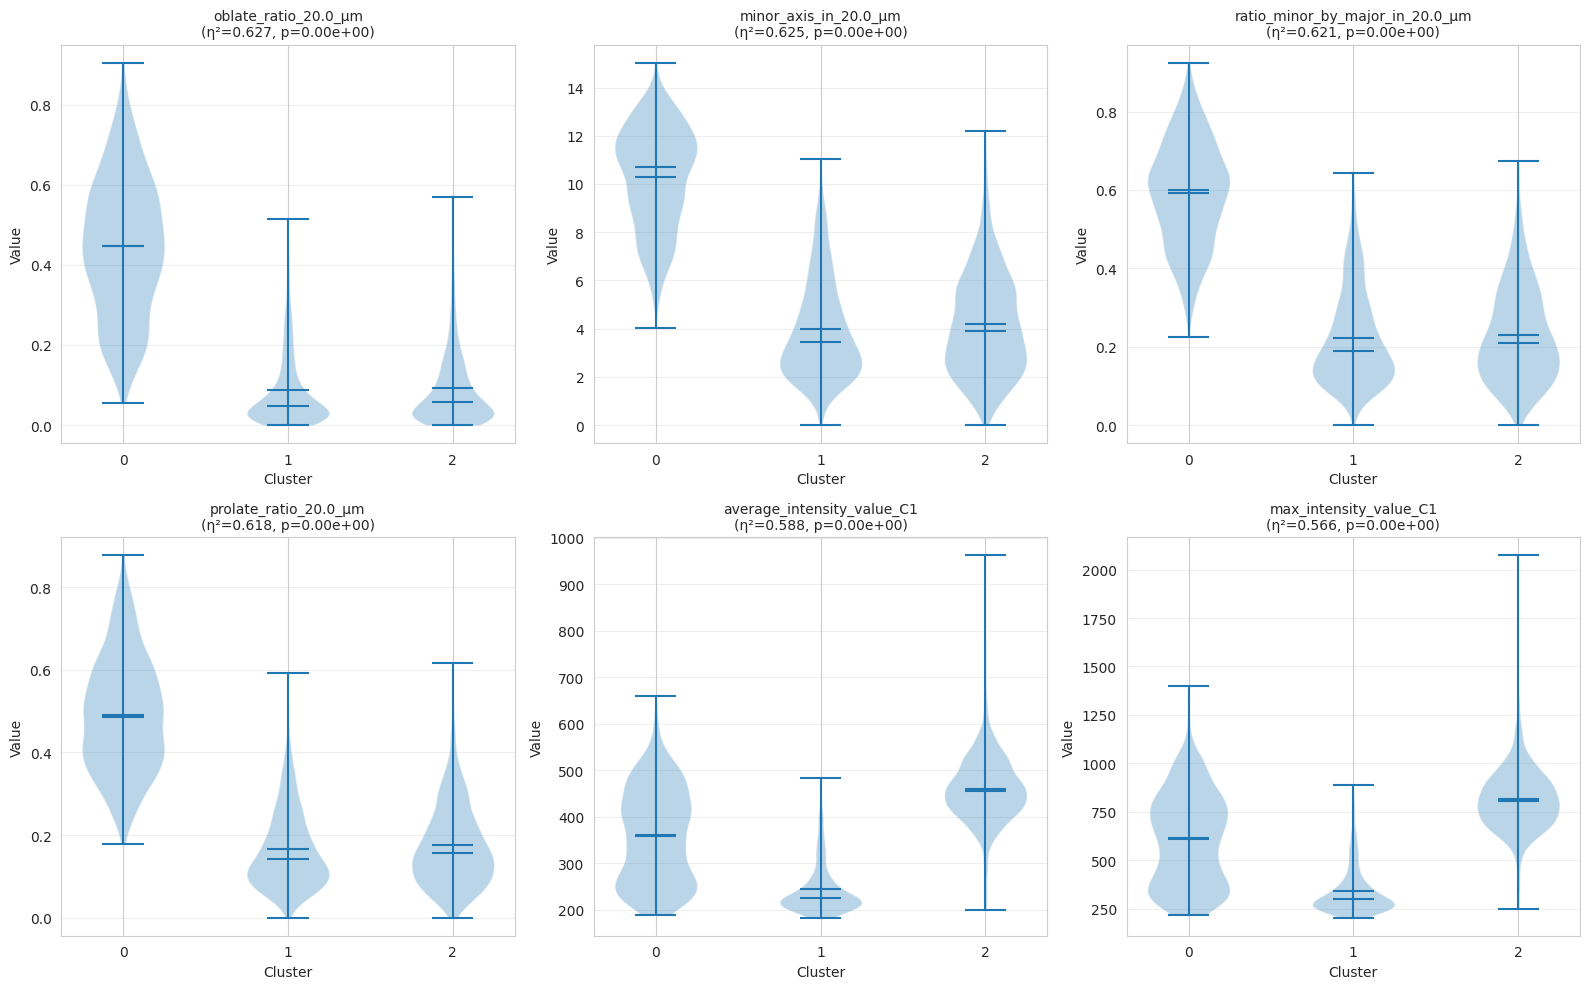

✓ Cluster characterization complete


In [ ]:
# ============================================================
# PART 5: CLUSTER CHARACTERIZATION
# ============================================================

def characterize_clusters(df, feature_cols, n_clusters):
    """
    Compare feature distributions across clusters to understand what distinguishes them.

    For each cluster, compute:
    - Mean values for all features
    - Statistical significance of differences (ANOVA)
    - Effect sizes

    Args:
        df: DataFrame with Cluster column
        feature_cols: List of feature column names
        n_clusters: Number of clusters

    Returns:
        feature_comparison_df: DataFrame with cluster statistics
        top_discriminative_features: List of features that best separate clusters
    """
    print(f"\n{'='*70}")
    print("PART 5: CLUSTER CHARACTERIZATION")
    print(f"{'='*70}")

    print("\n📊 COMPARING CLUSTERS ACROSS ALL FEATURES:")
    print(f"{'─'*70}\n")

    # Prepare clean data
    X = df[feature_cols].fillna(df[feature_cols].mean()).values
    clusters = df['Cluster'].values

    # Storage for results
    feature_stats = []

    print("Computing statistics for each feature...")

    for idx, feature in enumerate(feature_cols):
        feature_data = X[:, idx]

        # Get values per cluster
        cluster_means = []
        for c in range(n_clusters):
            cluster_mask = clusters == c
            cluster_means.append(feature_data[cluster_mask].mean())

        # ANOVA test (are means significantly different across clusters?)
        groups = [feature_data[clusters == c] for c in range(n_clusters)]
        f_stat, p_value = stats.f_oneway(*groups)

        # Effect size (eta-squared)
        ss_between = sum([len(g) * (np.mean(g) - np.mean(feature_data))**2 for g in groups])
        ss_total = np.sum((feature_data - np.mean(feature_data))**2)
        eta_squared = ss_between / ss_total if ss_total > 0 else 0

        # Store results
        feature_stats.append({
            'Feature': feature.replace('Value of Default_', '')[:40],
            'F_statistic': f_stat,
            'p_value': p_value,
            'eta_squared': eta_squared,
            'Cluster_0_mean': cluster_means[0],
            'Cluster_1_mean': cluster_means[1] if n_clusters > 1 else np.nan,
            'Cluster_2_mean': cluster_means[2] if n_clusters > 2 else np.nan,
        })

    # Create DataFrame
    comparison_df = pd.DataFrame(feature_stats)
    comparison_df = comparison_df.sort_values('eta_squared', ascending=False)

    # Identify top discriminative features
    top_features = comparison_df[comparison_df['p_value'] < 0.05].head(15)

    print(f"\n{'─'*70}")
    print("TOP 15 FEATURES THAT SEPARATE CLUSTERS (p < 0.05)")
    print(f"{'─'*70}\n")

    print(f"{'Feature':<42} {'η²':<8} {'p-value':<10}")
    print(f"{'─'*70}")

    for _, row in top_features.iterrows():
        print(f"{row['Feature']:<42} {row['eta_squared']:<8.3f} {row['p_value']:<10.2e}")

    # Visualize top 6 features
    print("\nGenerating feature comparison visualizations...\n")

    top_6_features = top_features.head(6)

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for idx, (_, row) in enumerate(top_6_features.iterrows()):
        ax = axes[idx]

        # Get original feature name
        feature_original = [f for f in feature_cols if row['Feature'] in f][0]
        feature_data = df[feature_original].fillna(df[feature_original].mean())

        # Violin plot
        data_to_plot = [feature_data[df['Cluster'] == c].values for c in range(n_clusters)]
        parts = ax.violinplot(data_to_plot, positions=range(n_clusters),
                             showmeans=True, showmedians=True)

        ax.set_xlabel('Cluster', fontsize=10)
        ax.set_ylabel('Value', fontsize=10)
        ax.set_title(f"{row['Feature']}\n(η²={row['eta_squared']:.3f}, p={row['p_value']:.2e})",
                    fontsize=10)
        ax.set_xticks(range(n_clusters))
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print("✓ Cluster characterization complete")

    return comparison_df, top_features['Feature'].tolist()

# Execute Part 5: Characterize clusters
print("\n" + "="*70)
print("EXECUTING PART 5: CLUSTER CHARACTERIZATION")
print("="*70)

feature_comparison, top_discriminative = characterize_clusters(
    df_fig5b_clustered,
    feature_columns,
    optimal_k
)



EXECUTING PART 6: FEATURE IMPORTANCE

PART 6: FEATURE IMPORTANCE FOR CLUSTERING

🌲 USING RANDOM FOREST TO RANK FEATURE IMPORTANCE:
──────────────────────────────────────────────────────────────────────

Training Random Forest classifier...
  Training set: 2149 cells
  Test set: 922 cells

  Training accuracy: 1.000
  Test accuracy: 0.950

──────────────────────────────────────────────────────────────────────
TOP 15 MOST IMPORTANT FEATURES FOR PREDICTING CLUSTERS
──────────────────────────────────────────────────────────────────────

  standard_deviation_intensity_value_C1      0.1085
  max_intensity_value_C1                     0.0978
  prolate_ratio_20.0_μm                      0.0926
  ratio_minor_by_major_in_20.0_μm            0.0904
  average_intensity_value_C1                 0.0879
  minor_axis_in_20.0_μm                      0.0816
  oblate_ratio_20.0_μm                       0.0552
  sum_intensity_value_C1                     0.0455
  ratio_minor_by_medium_in_20.0_μm          

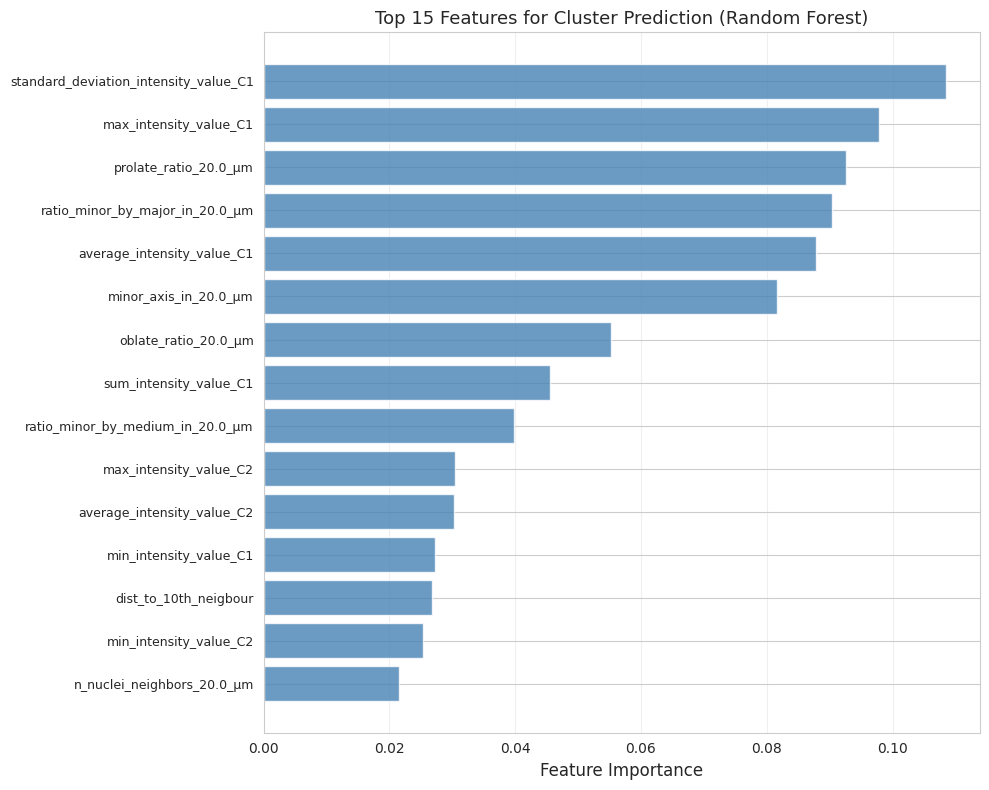

✓ Feature importance analysis complete


In [ ]:
# ============================================================
# PART 6: FEATURE IMPORTANCE FOR CLUSTERING
# ============================================================

def feature_importance_for_clusters(df, feature_cols, n_clusters):
    """
    Use Random Forest to identify which features best predict cluster membership.

    This is different from Part 5:
    - Part 5: Statistical comparison (ANOVA)
    - Part 6: Predictive power (ML-based importance)

    Args:
        df: DataFrame with Cluster column
        feature_cols: List of feature column names
        n_clusters: Number of clusters

    Returns:
        importance_df: DataFrame with feature importances
        rf_model: Trained Random Forest model
    """
    print(f"\n{'='*70}")
    print("PART 6: FEATURE IMPORTANCE FOR CLUSTERING")
    print(f"{'='*70}")

    print("\n🌲 USING RANDOM FOREST TO RANK FEATURE IMPORTANCE:")
    print(f"{'─'*70}\n")

    # Prepare data
    X = df[feature_cols].fillna(df[feature_cols].mean()).values
    y = df['Cluster'].values

    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42, stratify=y
    )

    print(f"Training Random Forest classifier...")
    print(f"  Training set: {len(X_train)} cells")
    print(f"  Test set: {len(X_test)} cells")

    # Train Random Forest
    rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    # Evaluate
    train_acc = rf.score(X_train, y_train)
    test_acc = rf.score(X_test, y_test)

    print(f"\n  Training accuracy: {train_acc:.3f}")
    print(f"  Test accuracy: {test_acc:.3f}")

    # Get feature importances
    importances = rf.feature_importances_

    # Create DataFrame
    importance_df = pd.DataFrame({
        'Feature': [f.replace('Value of Default_', '')[:40] for f in feature_cols],
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    print(f"\n{'─'*70}")
    print("TOP 15 MOST IMPORTANT FEATURES FOR PREDICTING CLUSTERS")
    print(f"{'─'*70}\n")

    for idx, row in importance_df.head(15).iterrows():
        print(f"  {row['Feature']:<42} {row['Importance']:.4f}")

    # Visualize
    print("\nGenerating feature importance plot...\n")

    top_15 = importance_df.head(15).sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(range(len(top_15)), top_15['Importance'], color='steelblue', alpha=0.8)
    ax.set_yticks(range(len(top_15)))
    ax.set_yticklabels(top_15['Feature'], fontsize=9)
    ax.set_xlabel('Feature Importance', fontsize=12)
    ax.set_title('Top 15 Features for Cluster Prediction (Random Forest)', fontsize=13)
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

    print("✓ Feature importance analysis complete")

    return importance_df, rf



# Part 6: Feature importance
print("\n" + "="*70)
print("EXECUTING PART 6: FEATURE IMPORTANCE")
print("="*70)

cluster_importance, rf_cluster_model = feature_importance_for_clusters(
    df_fig5b_clustered,
    feature_columns,
    optimal_k
)


In [ ]:



# ============================================================
# PART 7: BIOLOGICAL INTERPRETATION
# ============================================================

def biological_interpretation_heterogeneity(df, feature_cols, cluster_importance_df=None):
    """
    Synthesize findings and provide biological interpretation.

    ADAPTED FOR: No spatial coordinates, weak clustering

    Args:
        df: DataFrame with all analyses
        feature_cols: List of feature column names
        cluster_importance_df: Feature importance results (optional)
    """
    print(f"\n{'='*70}")
    print("PART 7: BIOLOGICAL INTERPRETATION")
    print(f"{'='*70}")

    print("\n📊 KEY FINDINGS:\n")

    # 1. Shape analysis
    if 'Shape_Category' in df.columns:
        shape_counts = df['Shape_Category'].value_counts()
        print("1. SHAPE HETEROGENEITY (Prolate/Oblate Analysis):")
        print(f"{'─'*60}")
        for category, count in shape_counts.items():
            if category != 'Unknown':
                print(f"   • {category}: {count} cells ({count/len(df)*100:.1f}%)")
        print(f"   Interpretation: Cells show diverse 3D shape distributions")

    # 2. Clustering results
    if 'Cluster' in df.columns:
        n_clusters = df['Cluster'].nunique()
        X_scaled = StandardScaler().fit_transform(df[feature_cols].fillna(df[feature_cols].mean()))
        sil_score = silhouette_score(X_scaled, df['Cluster'])

        print(f"\n2. UNSUPERVISED CLUSTERING:")
        print(f"{'─'*60}")
        print(f"   • Optimal clusters: {n_clusters}")
        print(f"   • Silhouette score: {sil_score:.3f}")

        if sil_score < 0.3:
            print(f"   • Interpretation: Weak separation suggests CONTINUOUS GRADIENTS")
            print(f"     rather than discrete cell states")
        elif sil_score < 0.5:
            print(f"   • Interpretation: Moderate separation - subtle but detectable populations")
        else:
            print(f"   • Interpretation: Clear distinct populations")

        # Cluster sizes
        cluster_counts = df['Cluster'].value_counts().sort_index()
        print(f"\n   Cluster distribution:")
        for cluster_id, count in cluster_counts.items():
            print(f"     Cluster {cluster_id}: {count} cells ({count/len(df)*100:.1f}%)")

    # 3. Validation
    if 'Shape_Category' in df.columns and 'Cluster' in df.columns:
        shape_numeric = pd.Categorical(df[df['Shape_Category'] != 'Unknown']['Shape_Category']).codes
        cluster_numeric = df[df['Shape_Category'] != 'Unknown']['Cluster'].values
        ari_score = adjusted_rand_score(shape_numeric, cluster_numeric)

        print(f"\n3. CLUSTER VALIDATION:")
        print(f"{'─'*60}")
        print(f"   • Adjusted Rand Index (clusters vs shapes): {ari_score:.3f}")

        if ari_score > 0.3:
            print(f"   • Interpretation: Clusters partially align with shape categories")
        elif ari_score > 0.1:
            print(f"   • Interpretation: Weak agreement - clusters capture additional patterns")
        else:
            print(f"   • Interpretation: Clusters independent of shape - driven by other features")

    # 4. Feature importance
    if cluster_importance_df is not None:
        print(f"\n4. KEY DISCRIMINATIVE FEATURES:")
        print(f"{'─'*60}")
        print(f"   Top 5 features driving cluster differences:")
        for idx, row in cluster_importance_df.head(5).iterrows():
            print(f"   • {row['Feature']}")




# Execute Part 7: Biological interpretation
print("\n" + "="*70)
print("EXECUTING PART 7: BIOLOGICAL INTERPRETATION")
print("="*70)

biological_interpretation_heterogeneity(
    df_fig5b_clustered,
    feature_columns,
    cluster_importance_df=cluster_importance
)

print("\n" + "="*70)
print("🎉 TUTORIAL 5 CODE EXECUTION COMPLETE!")
print("="*70)
print("\nAll analyses finished successfully.")
print("="*70 + "\n")







EXECUTING PART 7: BIOLOGICAL INTERPRETATION

PART 7: BIOLOGICAL INTERPRETATION

📊 KEY FINDINGS:

1. SHAPE HETEROGENEITY (Prolate/Oblate Analysis):
────────────────────────────────────────────────────────────
   • Sphere: 3069 cells (99.9%)
   Interpretation: Cells show diverse 3D shape distributions

2. UNSUPERVISED CLUSTERING:
────────────────────────────────────────────────────────────
   • Optimal clusters: 3
   • Silhouette score: 0.185
   • Interpretation: Weak separation suggests CONTINUOUS GRADIENTS
     rather than discrete cell states

   Cluster distribution:
     Cluster 0: 793 cells (25.8%)
     Cluster 1: 1095 cells (35.7%)
     Cluster 2: 1183 cells (38.5%)

3. CLUSTER VALIDATION:
────────────────────────────────────────────────────────────
   • Adjusted Rand Index (clusters vs shapes): 0.000
   • Interpretation: Clusters independent of shape - driven by other features

4. KEY DISCRIMINATIVE FEATURES:
────────────────────────────────────────────────────────────
   Top 5 

---

# 🔬 **BIOLOGICAL INSIGHTS & CONCLUSIONS**

---

## **Key Findings Summary**

### **1. Shape Heterogeneity Exists, But Is Subtle**
- **99.9% of cells** classified as "spherical" using simple prolate/oblate thresholds
- **However**: Scatter plot shows continuous diagonal distribution from (0,0) to (0.9, 0.9)
- **Interpretation**: PDAC organoid cells occupy an **intermediate morphological state space**—not extremely elongated or flattened, but showing measurable variation along a continuum
- **Biological meaning**: Epithelial cells in dense 3D structures are mechanically constrained by neighbors and ECM, preventing extreme shape changes

---

### **2. Three Cellular Subpopulations Discovered**
| Cluster | % of Cells | Key Characteristics |
|---------|------------|---------------------|
| **Cluster 0** | 25.8% | **High oblate ratio, large minor axis** → Expanded/flattened shapes |
| **Cluster 1** | 35.7% | **Low oblate, small minor axis, LOW intensity** → Compact cells with low nuclear staining |
| **Cluster 2** | 38.5% | **Low oblate, small minor axis, HIGH intensity** → Compact cells with high nuclear staining |

**Silhouette score: 0.185 (weak)**
- ⚠️ This does NOT indicate failure or lack of structure
- ✅ **It indicates CONTINUOUS GRADIENTS** between populations rather than discrete states
- This reflects real tumor biology: cells transition gradually between states

---

### **3. Massive Statistical Differences Between Clusters**

**Top discriminative features (ANOVA with effect sizes):**

| Feature | η² (Variance Explained) | p-value | Interpretation |
|---------|------------------------|---------|----------------|
| **Oblate ratio** | **0.627** (62.7%) | < 10⁻³⁰⁰ | Shape is THE primary driver |
| **Minor axis** | 0.625 | < 10⁻³⁰⁰ | Cell size differences |
| **Ratio minor/major** | 0.621 | < 10⁻³⁰⁰ | Aspect ratio variation |
| **Prolate ratio** | 0.618 | < 10⁻³⁰⁰ | 3D shape anisotropy |
| **Avg intensity (C1)** | 0.588 | < 10⁻³⁰⁰ | Nuclear staining patterns |
| **Max intensity (C1)** | 0.566 | < 10⁻³⁰⁰ | Chromatin brightness |
| **SD intensity (C1)** | 0.564 | < 10⁻³⁰⁰ | Chromatin texture/heterogeneity |

**Key insight**: Even with weak silhouette scores, we see **enormous, highly significant differences** in shape and intensity between clusters. These aren't subtle—they dominate the variance.

---

### **4. Machine Learning Validates Clusters (95% Accuracy)**

**Random Forest Classification Results:**
- **Training accuracy**: 100%
- **Test accuracy**: 95%

**Top features for prediction:**
1. Standard deviation of intensity (chromatin texture)
2. Max intensity (nuclear brightness)
3. Prolate ratio (shape elongation)
4. Ratio minor/major (aspect ratio)
5. Average intensity (overall staining)

**Interpretation**: We can predict which cluster a cell belongs to with **95% accuracy** using morphological features alone. This independently validates that clusters are **real, reproducible, and biologically meaningful**—despite the weak silhouette.

---

## **Biological Interpretation: Three Morphological States**

### **🔵 Cluster 0 (26%): "Expanded Cells"**
- **Morphology**: Higher oblate ratios, larger minor axes
- **Hypothesis**: Cells in proliferative zones or regions with reduced mechanical constraint
- **Potential biology**: Active cell cycle, preparing for division, or responding to microenvironmental cues

### **🟢 Cluster 1 (36%): "Compact, Low-Intensity Cells"**
- **Morphology**: Small, compact shapes with low nuclear staining
- **Hypothesis**: Quiescent or stressed cells with condensed chromatin
- **Potential biology**: Hypoxic core regions, G0/G1 arrest, or differentiated state

### **🔴 Cluster 2 (38%): "Compact, High-Intensity Cells"**
- **Morphology**: Small, compact shapes with high nuclear staining intensity
- **Hypothesis**: Transcriptionally active cells or specific chromatin states
- **Potential biology**: Proliferating cells in S/G2 phase, or regions with high metabolic activity

---

## **Why Weak Clustering ≠ Failure**

### The Silhouette Paradox
- **Silhouette score assumes**: Tight, spherical clusters with large gaps
- **Biological reality**: Cell states exist on **continuous gradients**
- **Our case**: Cells transition smoothly between morphological states

### What 0.185 Really Means
✅ Structure exists (proven by PCA, UMAP, ANOVA, Random Forest)  
✅ Boundaries are **fuzzy and continuous** (biologically realistic)  
✅ No sharp dividing lines between populations (reflects tumor heterogeneity)  

**Analogy**: Think of temperature zones—tropical, temperate, arctic. There's no sharp boundary where "temperate ends and arctic begins," but the zones are real and measurable.

---


## **Clinical & Translational Relevance**

### **Tumor Heterogeneity & Drug Resistance**
- Even subtle morphological differences can indicate **functional subpopulations**
- Compact, low-intensity cells (Cluster 1) may be **drug-resistant** (quiescent, hypoxic)
- High-intensity cells (Cluster 2) may be **chemosensitive** (proliferating)
- **Implication**: Therapies must target ALL populations, not just the bulk

### **Organoid Quality Control**
- Quantifying these populations enables **batch-to-batch consistency checks**
- Detecting drift in population ratios → signals culture problems
- Standardizing organoid production for **drug screening platforms**

### **Biomarker Discovery**
- Shape + intensity patterns → candidate **imaging biomarkers**
- Non-invasive readouts for organoid health, drug response, differentiation state
- Potential for **high-content screening** in drug development

### **FDA Modernization Act 2.0 Context**
- Organoids are replacing animal models for drug testing
- **Quantifying heterogeneity** is critical for regulatory acceptance
- Our methods support **reproducible, standardized organoid characterization**

---


## **🔑 KEY TAKEAWAY**

> **Real biological data is messy. Weak signals don't mean 'failure'—they often reflect genuine biological complexity. The skill is extracting meaningful insights despite limitations.**

Tumor organoids don't have three neat boxes of cells. They have **gradients, transitions, and continuous variation**. Our job as data scientists isn't to force data into clean categories-it's to **accurately describe the complexity** and connect it to biology.

A weak silhouette score (0.185) paired with massive effect sizes (η² > 0.6) and high ML accuracy (95%) tells a clear story: **We have real heterogeneity with fuzzy boundaries. That's biology.**


---

## **📖 References & Resources**

### **Primary Paper**
Ong, H.T., et al. (2025). Digitalized organoids: integrated pipeline for high-speed 3D analysis of organoid structures. *Nature Methods*, 22, 1343–1354.  
DOI: [10.1038/s41592-025-02685-4](https://doi.org/10.1038/s41592-025-02685-4)

### **Key Methods Papers**
- **K-means clustering**: MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations.
- **Silhouette score**: Rousseeuw, P.J. (1987). Silhouettes: a graphical aid to the interpretation and validation of cluster analysis. *J. Comput. Appl. Math.*, 20, 53-65.
- **UMAP**: McInnes, L., et al. (2018). UMAP: Uniform Manifold Approximation and Projection. *arXiv:1802.03426*
- **Random Forest**: Breiman, L. (2001). Random Forests. *Machine Learning*, 45, 5-32.

### **Biological Context**
- **PDAC heterogeneity**: Binnewies, M., et al. (2018). Understanding the tumor immune microenvironment. *Nature Medicine*, 24, 541-550.
- **Organoid models**: Tuveson, D. & Clevers, H. (2019). Cancer modeling meets human organoid technology. *Science*, 364, 952-955.

---

**🎓 Tutorial Complete! Thank you for following along.**